# Grain-Boundary Structure → Thermal Boundary Resistance

Analysis and ML pipeline built on the dataset produced by
`ml/format_cleaned_data.py` (`dataset.csv`). One row per grain boundary:

- **Geometry / identity** — `gb_label`, `sigma`, `gb_character` (twist / tilt /
  mixed), `tilt_type`, `misorientation_deg`, `inclination_deg`
- **Disorder descriptors** (atom subsets `full` and `gb10`) —
  `{subset}_sigma_theta`, `_sigma_l`, `_H_phi`, `_A_RDF`, `_rho`
- **GB energy** — `gamma_j_m2`, `gamma_ev_ang2`, …
- **rNEMD targets** — `R_K_mean` (Kapitza resistance ≡ thermal boundary
  resistance, TBR), `kappa_mean`, …

> Twist/tilt character and the misorientation/inclination angles are computed
> upstream by `utils/gb_geometry.py` and read straight from the CSV — this
> notebook never re-derives them. SOAP / Kernel-PCA / UMAP from the old pipeline
> have been removed (those columns no longer exist).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- Configuration -------------------------------------------------------
DATASET = "/projects/p33174/PSED_results/full/dataset.csv"
SUBSET  = "gb10"          # atom subset used for the "measures of disorder"
TARGET  = "R_K_mean"      # thermal boundary resistance (Kapitza resistance)
RANDOM_STATE = 42

# The five structural measures of disorder (per subset).
DESC_NAMES  = ["sigma_theta", "sigma_l", "H_phi", "A_RDF", "rho"]
DESC_COLS   = [f"{SUBSET}_{m}" for m in DESC_NAMES]
DESC_LABELS = {
    f"{SUBSET}_sigma_theta": r"$\sigma_\theta$ (deg)",
    f"{SUBSET}_sigma_l":     r"$\sigma_l$ (Å)",
    f"{SUBSET}_H_phi":       r"$H_\phi$ (nats)",
    f"{SUBSET}_A_RDF":       r"$A_\mathrm{RDF}$",
    f"{SUBSET}_rho":         r"$\rho$ (atoms/Å³)",
}

# Consistent colors for GB character across every plot.
CHAR_COLORS = {"twist": "#1f77b4", "tilt": "#ff7f0e", "mixed": "#2ca02c"}

# ---- Load ----------------------------------------------------------------
df = pd.read_csv(DATASET)

print(f"Loaded {len(df)} grain boundaries x {df.shape[1]} columns")
print(f"Sigma values: {sorted(df['sigma'].unique())}")
print("\nGB character:\n" + df["gb_character"].value_counts().to_string())
print("\nTilt type:\n" + df["tilt_type"].value_counts(dropna=False).to_string())
print(f"\nRows with {TARGET}:     {df[TARGET].notna().sum()}/{len(df)}")
print(f"Rows with gamma_j_m2: {df['gamma_j_m2'].notna().sum()}/{len(df)}")

Loaded 15 grain boundaries x 36 columns
Sigma values: [np.int64(5), np.int64(13), np.int64(17)]

GB character:
gb_character
tilt     12
twist     3

Tilt type:
tilt_type
symmetric    12
NaN           3

Rows with R_K_mean:     15/15
Rows with gamma_j_m2: 0/15


## 1. Distributions of the gb10 disorder descriptors

Histograms of the five structural measures computed over atoms within 10 Å of
the grain-boundary plane.

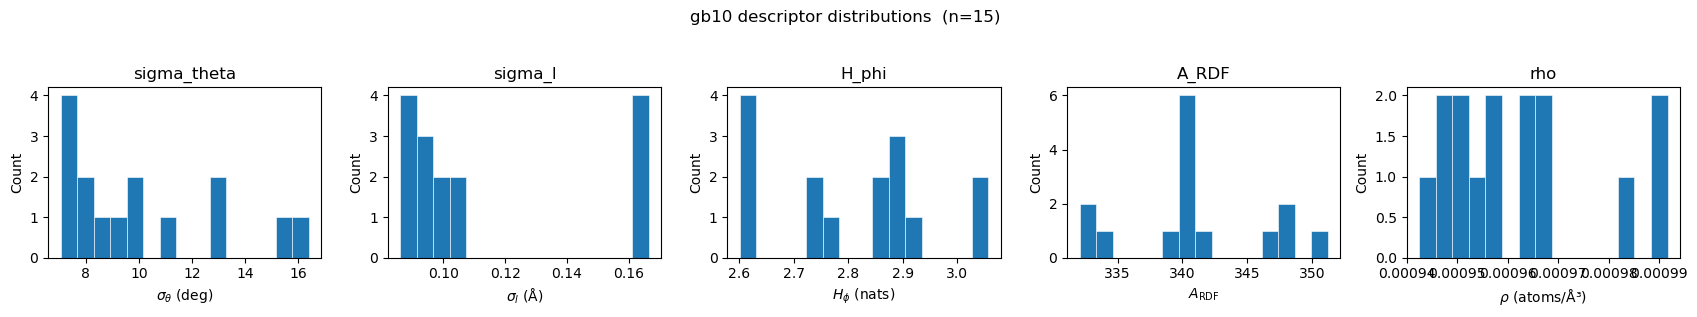

In [2]:
present = [c for c in DESC_COLS if c in df.columns]
fig, axes = plt.subplots(1, len(present), figsize=(3.4 * len(present), 3))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, present):
    vals = df[col].dropna()
    ax.hist(vals, bins=min(30, max(5, len(vals))), edgecolor="white", linewidth=0.4)
    ax.set_xlabel(DESC_LABELS.get(col, col))
    ax.set_ylabel("Count")
    ax.set_title(col.replace(f"{SUBSET}_", ""))
fig.suptitle(f"{SUBSET} descriptor distributions  (n={len(df)})", y=1.04)
fig.tight_layout()
plt.show()

## 2. PCA of the disorder measures, colored by GB character

Standardize the five gb10 descriptors and project onto the first two principal
components. Points are colored by twist/tilt character (primary), with a
sigma-colored panel for context. The loading matrix shows which descriptors
drive each PC.

Explained variance ratio: [0.7   0.241]

Loadings:
               PC1    PC2
sigma_theta  0.485  0.362
sigma_l      0.513  0.143
H_phi        0.438  0.414
A_RDF        0.451 -0.456
rho         -0.327  0.685


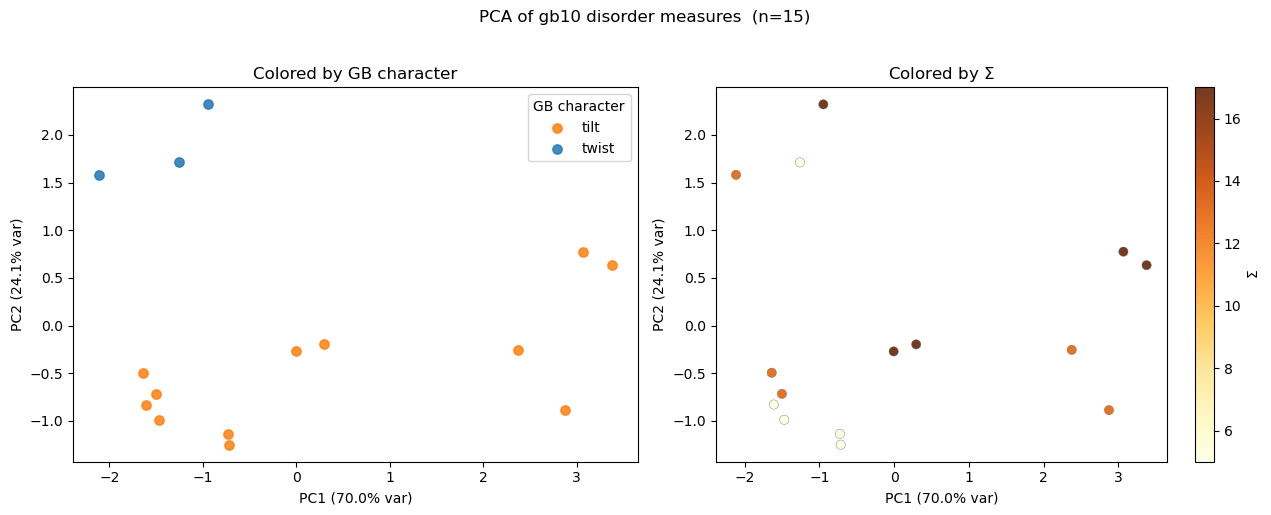

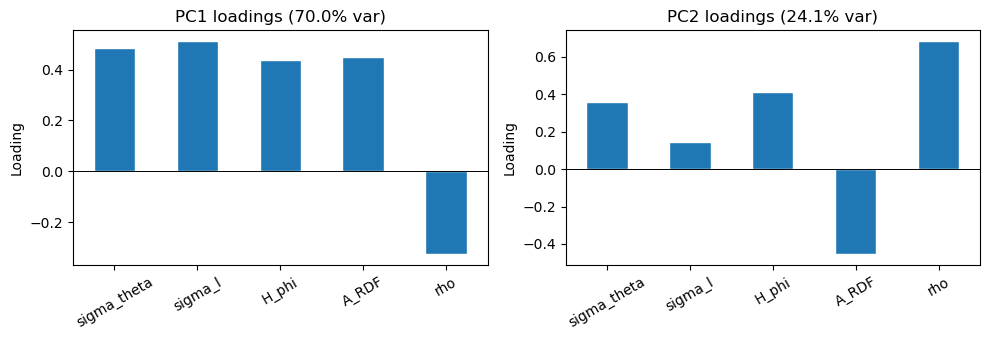

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_mask = df[DESC_COLS].notna().all(axis=1)
X_desc = df.loc[pca_mask, DESC_COLS].values
chars  = df.loc[pca_mask, "gb_character"].values
sigmas = df.loc[pca_mask, "sigma"].values

if len(X_desc) < 3:
    print(f"Only {len(X_desc)} rows with complete descriptors (need >=3). Skipping PCA.")
else:
    X_scaled = StandardScaler().fit_transform(X_desc)
    pca = PCA(n_components=2).fit(X_scaled)
    X_pca = pca.transform(X_scaled)
    evr = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=[c.replace(f"{SUBSET}_", "") for c in DESC_COLS],
        columns=["PC1", "PC2"],
    )
    print("Explained variance ratio:", np.round(evr, 3))
    print("\nLoadings:\n" + loadings.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ch in pd.unique(chars):
        m = chars == ch
        axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=45, alpha=0.85,
                        color=CHAR_COLORS.get(ch, "gray"), label=ch)
    axes[0].legend(title="GB character")
    axes[0].set_title("Colored by GB character")
    sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=sigmas, cmap="YlOrBr",
                         s=45, alpha=0.9, edgecolor="0.4", linewidth=0.3)
    plt.colorbar(sc, ax=axes[1], label="$\\Sigma$")
    axes[1].set_title("Colored by $\\Sigma$")
    for ax in axes:
        ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)")
        ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
    fig.suptitle(f"PCA of {SUBSET} disorder measures  (n={len(X_pca)})", y=1.02)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, pc in zip(axes, ["PC1", "PC2"]):
        loadings[pc].plot(kind="bar", ax=ax, edgecolor="white")
        ax.axhline(0, color="k", linewidth=0.7)
        ax.set_title(f"{pc} loadings ({evr[int(pc[-1]) - 1]:.1%} var)")
        ax.set_ylabel("Loading")
        ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

## 3. Descriptive statistics of R_K

Mean, standard deviation, and count of the thermal boundary resistance
`R_K_mean`, aggregated by CSL $\Sigma$ and by twist/tilt character, plus the
$\Sigma \times$ character breakdown.

=== R_K_mean by Sigma ===
               mean           std  count
sigma                                   
5      4.262055e-09  1.263597e-09      5
13     3.867448e-09  3.131205e-10      5
17     5.412814e-09  5.863145e-10      5

=== R_K_mean by GB character ===
                      mean           std  count
gb_character                                   
tilt          4.334505e-09  8.409477e-10     12
twist         5.232508e-09  1.563058e-09      3

=== mean R_K_mean:  Sigma x character ===
gb_character          tilt         twist
sigma                                   
5             3.699878e-09  6.510762e-09
13            3.961839e-09  3.489886e-09
17            5.341799e-09  5.696877e-09


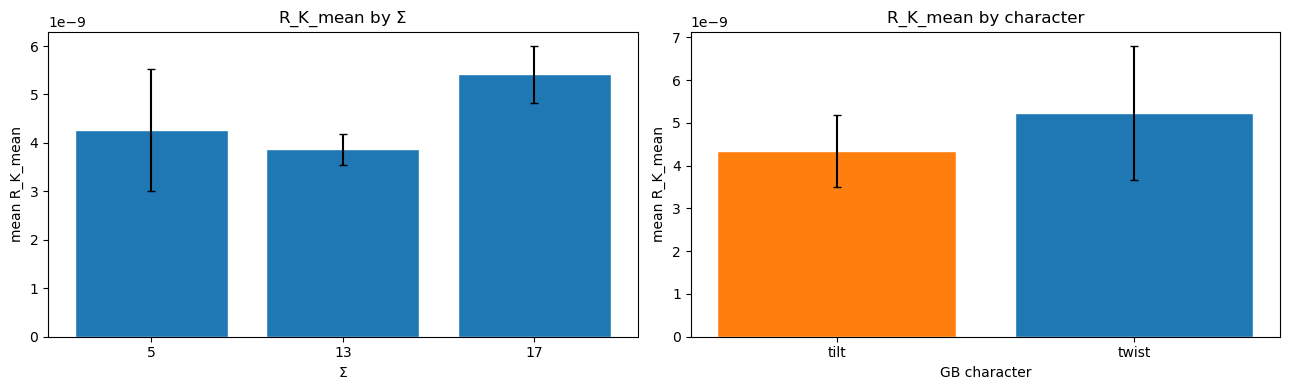

In [4]:
rk = df[df[TARGET].notna()].copy()
if len(rk) == 0:
    print(f"No rows with {TARGET} yet -- skipping descriptive statistics.")
else:
    by_sigma = rk.groupby("sigma")[TARGET].agg(["mean", "std", "count"])
    by_char  = rk.groupby("gb_character")[TARGET].agg(["mean", "std", "count"])
    pivot    = rk.pivot_table(index="sigma", columns="gb_character",
                              values=TARGET, aggfunc="mean")

    print(f"=== {TARGET} by Sigma ===\n" + by_sigma.to_string())
    print(f"\n=== {TARGET} by GB character ===\n" + by_char.to_string())
    print(f"\n=== mean {TARGET}:  Sigma x character ===\n" + pivot.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(by_sigma.index.astype(str), by_sigma["mean"],
                yerr=by_sigma["std"].fillna(0), capsize=3, edgecolor="white")
    axes[0].set_xlabel("$\\Sigma$"); axes[0].set_ylabel(f"mean {TARGET}")
    axes[0].set_title(f"{TARGET} by $\\Sigma$")

    colors = [CHAR_COLORS.get(c, "gray") for c in by_char.index]
    axes[1].bar(by_char.index, by_char["mean"], yerr=by_char["std"].fillna(0),
                capsize=3, color=colors, edgecolor="white")
    axes[1].set_xlabel("GB character"); axes[1].set_ylabel(f"mean {TARGET}")
    axes[1].set_title(f"{TARGET} by character")
    fig.tight_layout()
    plt.show()

## 4. GB energy vs thermal boundary resistance

Relationship between the relaxed GB formation energy `gamma_j_m2` ($\gamma$) and
the Kapitza resistance `R_K_mean`. Error bars use the per-GB std columns where
available.

In [5]:
ev = df[df["gamma_j_m2"].notna() & df[TARGET].notna()]
if len(ev) == 0:
    print("GB energy (gamma_j_m2) not yet computed for any row with a target --"
          " skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)")
else:
    x = ev["gamma_j_m2"].to_numpy()
    y = ev[TARGET].to_numpy()
    yerr = ev["R_K_std"].to_numpy() if "R_K_std" in ev else None

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for ch in pd.unique(ev["gb_character"]):
        m = (ev["gb_character"] == ch).to_numpy()
        ax.errorbar(x[m], y[m], yerr=None if yerr is None else yerr[m],
                    fmt="o", ms=6, alpha=0.85, capsize=2,
                    color=CHAR_COLORS.get(ch, "gray"), label=ch)
    ax.set_xlabel(r"$\gamma$ (J/m$^2$)"); ax.set_ylabel(TARGET)
    ax.set_title("GB energy vs TBR")
    ax.legend(title="GB character")
    fig.tight_layout()
    plt.show()

    if len(ev) >= 3:
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        print(f"Pearson  r = {r_p:+.3f}  (p = {p_p:.3g})")
        print(f"Spearman rho = {r_s:+.3f}  (p = {p_s:.3g})")
    else:
        print(f"Only {len(ev)} points -- correlation not meaningful.")

GB energy (gamma_j_m2) not yet computed for any row with a target -- skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)


## 5. Misorientation and inclination angle vs R_K

Misorientation is fixed per (axis, $\Sigma$); inclination measures the boundary
plane's rotation away from the nearest symmetric tilt plane (NaN for
twist/mixed, ~0 for symmetric tilt).

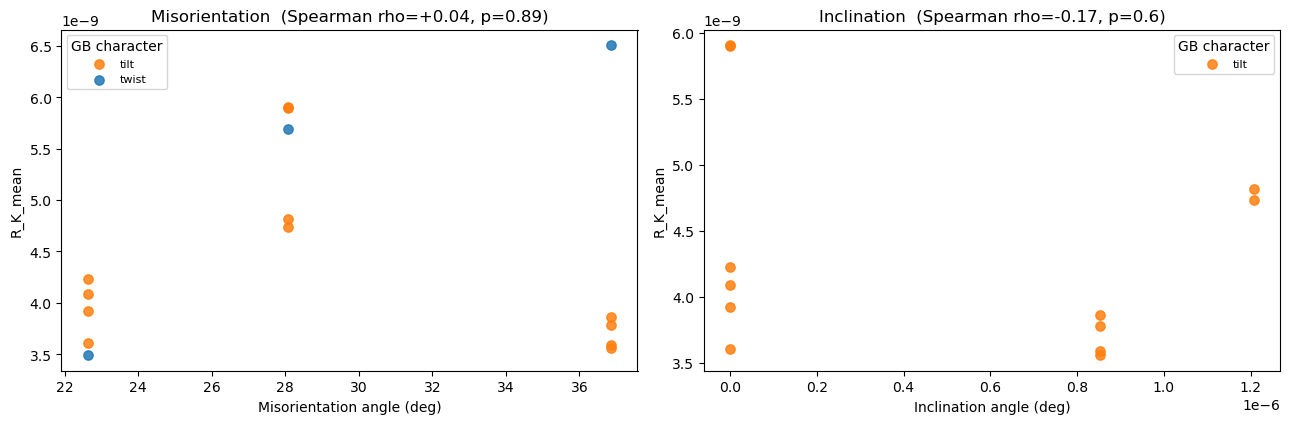

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (angle_col, title) in zip(axes, [
    ("misorientation_deg", "Misorientation"),
    ("inclination_deg",    "Inclination"),
]):
    sub = df[df[angle_col].notna() & df[TARGET].notna()]
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No data for {angle_col}", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(title)
        continue
    for ch in pd.unique(sub["gb_character"]):
        m = sub["gb_character"] == ch
        ax.scatter(sub.loc[m, angle_col], sub.loc[m, TARGET], s=45, alpha=0.85,
                   color=CHAR_COLORS.get(ch, "gray"), label=ch)
    ax.set_xlabel(f"{title} angle (deg)"); ax.set_ylabel(TARGET)
    ax.legend(title="GB character", fontsize=8)
    if sub[angle_col].nunique() >= 3 and len(sub) >= 3:
        r_s, p_s = stats.spearmanr(sub[angle_col], sub[TARGET])
        ax.set_title(f"{title}  (Spearman rho={r_s:+.2f}, p={p_s:.2g})")
    else:
        ax.set_title(f"{title}  (n={len(sub)}, {sub[angle_col].nunique()} unique x)")
fig.tight_layout()
plt.show()

## 6. Predicting R_K — multi-model regression with stratified nested CV

With only ~50 grain boundaries, a single held-out test set is too noisy. We
estimate out-of-sample error with **nested cross-validation**:

- **Outer loop** — `StratifiedKFold` stratified by $\Sigma$. Under-populated
  $\Sigma$ (fewer members than the fold count) are pooled into one `"rare"`
  stratum so stratification stays valid. Each outer fold yields a genuine
  out-of-sample score.
- **Inner loop** — `GridSearchCV` tunes each model's hyperparameters using only
  the outer-training data (no leakage).

Models: Ridge (the tunable linear regression), KNN, RandomForest, XGBoost, MLP
(neural net), plus a mean baseline. Features are the five gb10 disorder
measures; target is `R_K_mean`.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

FEATURES = list(DESC_COLS)   # easy to extend, e.g. + ["misorientation_deg"]

mldf = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
X = mldf[FEATURES].to_numpy()
y = mldf[TARGET].to_numpy()
print(f"Modeling on {len(mldf)} GBs, {len(FEATURES)} features, target = {TARGET}")


def make_strata(sigma_vals, k):
    '''Sigma-based strata; any Sigma with < k members is pooled into 'rare'
    (label -1) so StratifiedKFold(k) is valid. Returns (strata, pooled_list).'''
    s = pd.Series(sigma_vals)
    counts = s.value_counts()
    rare = counts[counts < k].index
    strata = s.where(~s.isin(rare), other=-1).astype(int).to_numpy()
    return strata, sorted(int(v) for v in rare)


def build_models():
    '''name -> (pipeline, param_grid). Scaler is harmless for trees, needed for
    Ridge / KNN / MLP.'''
    return {
        "Ridge": (
            Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
            {"m__alpha": [1e-3, 1e-2, 1e-1, 1, 10, 100]},
        ),
        "KNN": (
            Pipeline([("sc", StandardScaler()), ("m", KNeighborsRegressor())]),
            {"m__n_neighbors": [3, 5, 7, 9], "m__weights": ["uniform", "distance"]},
        ),
        "RandomForest": (
            Pipeline([("sc", StandardScaler()),
                      ("m", RandomForestRegressor(random_state=RANDOM_STATE))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [None, 3, 5],
             "m__max_features": ["sqrt", 1.0]},
        ),
        "XGBoost": (
            Pipeline([("sc", StandardScaler()),
                      ("m", XGBRegressor(random_state=RANDOM_STATE, n_jobs=1,
                                         objective="reg:squarederror"))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [2, 3],
             "m__learning_rate": [0.03, 0.1], "m__subsample": [0.8, 1.0]},
        ),
        "MLP": (
            Pipeline([("sc", StandardScaler()),
                      ("m", MLPRegressor(random_state=RANDOM_STATE, max_iter=3000))]),
            {"m__hidden_layer_sizes": [(16,), (32,), (32, 16)],
             "m__alpha": [1e-3, 1e-2, 1e-1]},
        ),
        "Baseline (mean)": (
            Pipeline([("m", DummyRegressor(strategy="mean"))]),
            {},
        ),
    }

Modeling on 15 GBs, 5 features, target = R_K_mean


In [ ]:
N_OUTER = 5

if len(mldf) < 2 * N_OUTER:
    print(f"Only {len(mldf)} usable rows (< {2 * N_OUTER}); skipping cross-validation.\n"
          "The dataset is still being generated -- re-run this section once "
          "dataset.csv is more complete.")
    cv_results = None
else:
    # Shrink fold count until every (pooled) stratum has >= k members.
    k = N_OUTER
    while k > 2:
        strata, pooled = make_strata(mldf["sigma"].to_numpy(), k)
        if pd.Series(strata).value_counts().min() >= k:
            break
        k -= 1
    strata, pooled = make_strata(mldf["sigma"].to_numpy(), k)
    if pooled:
        print(f"Pooled under-populated Sigma into 'rare' stratum: {pooled}")
    print(f"Outer CV: StratifiedKFold(n_splits={k}) stratified by Sigma\n")

    outer = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    inner = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # silence MLP convergence chatter
        for name, (pipe, grid) in build_models().items():
            f_rmse, f_mae, f_r2 = [], [], []
            for tr, te in outer.split(X, strata):
                if grid:
                    search = GridSearchCV(pipe, grid, cv=inner,
                                          scoring="neg_root_mean_squared_error",
                                          n_jobs=-1)
                    search.fit(X[tr], y[tr])
                    est = search.best_estimator_
                else:
                    est = pipe.fit(X[tr], y[tr])
                pred = est.predict(X[te])
                f_rmse.append(np.sqrt(mean_squared_error(y[te], pred)))
                f_mae.append(mean_absolute_error(y[te], pred))
                f_r2.append(r2_score(y[te], pred))
            rows.append({
                "model": name,
                "RMSE_mean": np.mean(f_rmse), "RMSE_std": np.std(f_rmse),
                "MAE_mean": np.mean(f_mae),   "MAE_std": np.std(f_mae),
                "R2_mean": np.mean(f_r2),     "R2_std": np.std(f_r2),
            })
            print(f"  {name:16s} RMSE={np.mean(f_rmse):.3e} +/- {np.std(f_rmse):.1e}   "
                  f"R2={np.mean(f_r2):+.3f}")

    cv_results = pd.DataFrame(rows).set_index("model")
    print("\n=== Nested-CV out-of-sample performance ===")
    print(cv_results.round(4).to_string())

Outer CV: StratifiedKFold(n_splits=5) stratified by Sigma



In [ ]:
if cv_results is None:
    print("No CV results to plot.")
else:
    order = cv_results["RMSE_mean"].sort_values().index
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(order, cv_results.loc[order, "RMSE_mean"],
                yerr=cv_results.loc[order, "RMSE_std"], capsize=3, edgecolor="white")
    axes[0].set_ylabel("RMSE"); axes[0].set_title("Out-of-sample RMSE (lower is better)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[1].bar(order, cv_results.loc[order, "R2_mean"],
                yerr=cv_results.loc[order, "R2_std"], capsize=3, edgecolor="white")
    axes[1].axhline(0, color="k", linewidth=0.7)
    axes[1].set_ylabel("$R^2$"); axes[1].set_title("Out-of-sample $R^2$ (higher is better)")
    axes[1].tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

In [ ]:
# Refit the best model on all data and inspect coefficients / importances.
if cv_results is None:
    print("No model to refit.")
else:
    best_name = cv_results["RMSE_mean"].idxmin()
    print(f"Best model by out-of-sample RMSE: {best_name}")

    pipe, grid = build_models()[best_name]
    if grid:
        search = GridSearchCV(
            pipe, grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
            scoring="neg_root_mean_squared_error", n_jobs=-1)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            search.fit(X, y)
        best = search.best_estimator_
        print("Best hyperparameters:", search.best_params_)
    else:
        best = pipe.fit(X, y)

    est = best.named_steps["m"]
    imp, title = None, None
    if hasattr(est, "feature_importances_"):
        imp = pd.Series(est.feature_importances_, index=FEATURES).sort_values()
        title = f"{best_name} feature importances"
    elif hasattr(est, "coef_"):
        imp = pd.Series(np.ravel(est.coef_), index=FEATURES).sort_values()
        title = f"{best_name} coefficients (standardized features)"

    if imp is not None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
        imp.plot(kind="barh", ax=ax, edgecolor="white")
        ax.axvline(0, color="k", linewidth=0.7)
        ax.set_title(title)
        fig.tight_layout()
        plt.show()
    else:
        print(f"{best_name} exposes no simple importance/coefficient summary.")